# Formulas de Newton-Cotes

# Regla del trapecio

Considere el polinomio de interpolación $P_1(x)$ de primer grado que pasa por $(x_0, y_0), (x_1, y_1) $. El polinomio de interpolación con su término de error es:

$$f(x) = y_0*\frac{x - x_1}{x_0 - x_1} + y_1 * \frac{x - x_0}{x_1 - x_0} + \frac{(x - x_0)(x - x_1)}{2!}f''(c_x) = P(x) + E(x) $$

Integrando el polinomio:

$$\int_{x_0}^{x_1} f(x) dx = \int_{x_0}^{x_1} P(x) dx + \int_{x_0}^{x_1} E(x) dx $$

Se llega al resultado:

$$\int_{x_0}^{x_1} f(x) dx = \frac{h}{2}(y_0 + y_1) - \frac{h^3}{12}f''(c)$$

Donde $ h = x_1 - x_0 $ y c está entre $x_0$ y $x_1$

# Regla de Simpson

Se procede de manera similar que con la regla del trapecio, solo que se toma el polinomio de Lagrange de segundo grado.

$$f(x) = y_0\frac{(x-x_1)(x-x_2)}{(x_0-x_1)(x_0-x_2)} + y_1\frac{(x-x_0)(x-x_2)}{(x_1-x_0)(x_1-x_2)} + y_2\frac{(x-x_0)(x-x_1)}{(x_2-x_0)(x_2-x_1)} + \frac{(x - x_0)(x - x_1)(x - x_2)}{3!}f'''(c_x) = P(x) + E(x) $$

Integrando:

$$\int_{x_0}^{x_2} f(x) dx = \int_{x_0}^{x_2} P(x) dx + \int_{x_0}^{x_2} E(x) dx $$

Se llega al resultado:

$$\int_{x_0}^{x_2} f(x) dx = \frac{h}{3}(y_0 + 4y_1 + y_2) - \frac{h^5}{90}f^{(4)}(c)$$

Donde $ h = x_2 - x_1 = x_1 - x_0 $ y c está entre $x_0$ y $x_2$




In [10]:
# Regla del trapecio
import numpy as np

def f(x):
    return np.log(x)

def F(a, b):
    return b*np.log(b) - a*np.log(a) - 1


def trapecio(a, b, f):
    h = (b-a)
    return (h/2)*(f(a) + f(b))

def funcion_error(a, b, c):
    h = (b - a)

    return np.abs(h**3/(12*c**2))

aprox = trapecio(1,2, f)
exacta = F(1,2)
error = np.abs(exacta - aprox)
cota_s = funcion_error(1,2,1)

print(f"{'exacta':<{15}}{'aprox':<{15}}{'error':<{15}}")
print(f"{exacta:<{15}.10f}{aprox:<{15}.10f}{error:<{15}e}")
print(f"Cota superior del error: {cota_s}")



exacta         aprox          error          
0.3862943611   0.3465735903   3.972077e-02   
Cota superior del error: 0.08333333333333333


In [14]:
# Regla de Simpson
import numpy as np

def f(x):
    return np.log(x)

def F(a, b):
    return b*np.log(b) - a*np.log(a) - 1


def simpson(a, b, f):
    x2 = (b + a)/2
    h = b - x2
    return (h/3)*(f(a) + 4*f(x2) + f(b))

def funcion_error(a, b, c):
    h = b - (b + a)/2
    return np.abs(6*h**5/(90*c**4))

aprox = simpson(1,2, f)
exacta = F(1,2)
error = np.abs(exacta - aprox)
cota_s = funcion_error(1,2,1)

print(f"{'exacta':<{15}}{'aprox':<{15}}{'error':<{15}}")
print(f"{exacta:<{15}.10f}{aprox:<{15}.10f}{error:<{15}e}")
print(f"Cota superior del error: {cota_s}")

exacta         aprox          error          
0.3862943611   0.3858346022   4.597590e-04   
Cota superior del error: 0.0020833333333333333


El grado de precisión de un método de integración numérica es el grado k o menor, del polinomio que se usa para integrar. Las fórmulas anteriores son fórmulas de Newton-Cotes cerradas, es decir, incluyen evaluaciones de los extremos finales del intervalo. 

# Fórmulas de Newton-Cotes compuestas

Las reglas compuestas se obtienen al dividir el intervalo, en varios subintervalos y aplicar la regla por separado a cada uno. Para aproximar:

$$\int_{a}^{b} f(x) dx$$

Se considera una cuadrícula uniformemente espaciada:

$$a = x_0 < x_1 < x_2 < ... < x_{m-2} < x_{m-1} < x_m = b$$

En cada intervalo se aplica, la regla del trapecio. Sumando todas las integrales se obtiene:

$$\sum_{a}^{b} = \frac{h}{2} \left( f(a) + f(b) + 2\sum_{i = 1}^{m-1}f(x_i) \right) - \sum_{i = 0}^{m-1} \frac{h^3}{12}f''(c_i) $$

$$mh = (b-a)$$

# Regla del trapecio compuesta

$$\sum_{a}^{b} = \frac{h}{2} \left( f(a) + f(b) + 2\sum_{i = 1}^{m-1}f(x_i) \right) - \frac{(b-a)h^2}{12}mf''(c) $$

Donde $h = \frac{b-a}{m}$ y c está entre a y b

---

Para la regla de Simpson se realiza el mismo proceso sobre una cuadrícula uniformemente espaciada:

$$\sum_{a}^{b}f(x)dx = \frac{h}{3} \left(f(a) + f(b) + 4\sum_{i=1,3,..}^{m-1}f(x_i) + 2\sum_{i = 2,4,...}^{m-2} f(x_i)\right) - \sum_{i = 0}^{m-1} \frac{h^5}{90}f^{(4)}(c_i) $$

$$\sum_{a}^{b}f(x)dx = \frac{h}{3} \left(f(a) + f(b) + 4\sum_{i=1}^{m}f(x_{2i - 1}) + 2\sum_{i = 1}^{m-1} f(x_{2i})\right) - \sum_{i = 0}^{m-1} \frac{h^5}{90}f^{(4)}(c_i) $$

Donde $m2h = (b-a)$

$$\sum_{a}^{b}f(x)dx = \frac{h}{3} \left(f(a) + f(b) + 4\sum_{i=1}^{m}f(x_{2i - 1}) + 2\sum_{i = 1}^{m-1} f(x_{2i})\right) - \frac{(b-a)h^4}{180}f^{(4)}(c) $$


In [70]:
# Regla del Trapecio compuesta

import numpy as np

def trapecio_compuesta(f, a, b, n):
    x = np.linspace(a,b,n+1)
    h = (b-a)/n
    y = f(x)
    return (h/2)*(y[0] + y[n] + 2*np.sum(y[1:n]))

def f(x):
    return np.log(x)

def funcion_error(c, a, b, n):
    h = (b-a)/n
    return ((b-a)*h**2)/(12*c**2)
    
aprox = trapecio_compuesta(f, 1, 2, 4)
cota_s = funcion_error(1, 1, 2, 4)
print(f"Aproximación: {aprox}")
print(f"Cota superior del error: {cota_s:e}")




Aproximación: 0.38369950940944236
Cota superior del error: 5.208333e-03


In [58]:
# Regla de simpson compuesta

import numpy as np

def simpson_compuesta(f, a, b, n):

    if n % 2 != 0:
        raise ValueError("n debe ser par")

    h = (b-a)/n

    x = np.linspace(a, b, n+1)
    print(x)
    y = f(x)
    return (h/3)*(y[0] + y[n] + 4*np.sum(y[1:n:2]) + 2*np.sum(y[2:n:2]))

def f(x):
    return np.log(x)

def funcion_error(c, a, b, n):
    h = (b-a)/n
    return ((b-a)*6*h**4)/(180*c**4)

aprox = simpson_compuesta(f, 1, 2, 8)
cota_s = funcion_error(1, 1, 2, 8)
print(f"Aproximación: {aprox}")
print(f"Cota superior del error: {cota_s:e}")

[1.    1.125 1.25  1.375 1.5   1.625 1.75  1.875 2.   ]
Aproximación: 0.3862920434663129
Cota superior del error: 8.138021e-06


# Métodos abiertos

# Regla del punto medio

Son útiles cuando evaluar el integrando en uno de los extremos de la integral conduce a una singularidad, los métodos abiertos no utilizan valores en los puntos extremos.

$$\sum_{x_0}^{x_1} f(x) dx = hf(w) + \frac{h^3}{24}f''(c)$$

Donde $h = (x_1 - x_0)$, w es el punto medio $x_0 + \frac{h}{2}$ y c está entre $x_0$ y $x_1$.

La demostración es la misma que con la regla del trapecio, simplemente se usa un polinomio de interpolación lineal alrededor del punto medio $w = x_0 + \frac{h}{2}$:

$$f(x) = f(w) + (x-w)f'(w) + \frac{1}{2}(x-w)^2f''(c_x)$$

Luego debe integrarse $f(x)$ entre $x_0$ y $x_1$

El resultado será:

$$\sum_{x_0}^{x_1} f(x) dx = hf(w) + \frac{h^3}{24}f''(c)$$

Donde c es un valor entre $x_0$ y $x_1$

Una regla compuesta del punto medio sería:

$$\sum_{a}^{b} f(x) dx = h \sum_{i=1}^{m}f(w_i) + \frac{(b-a)h^3}{24}f''(c)$$

donde $h = (b-a)/m$ y c está entre a y b. Las $w_i$ son los puntos medios de los m subintervalos




In [69]:
import numpy as np

def punto_medio_compuesta(f, a, b, n):
    
    h = (b-a)/n

    x = np.linspace(a + h/2, b - h/2, n)

    y = f(x)
    return h*np.sum(y)

def f(x):
    return np.sin(x)/x

aprox = punto_medio_compuesta(f, 0, 1, 10)
print(aprox)

0.9462085788431454


# Integración de Romberg

El error de la regla del trapecio, puede demostrarse, que para una función f infinitamente diferenciable puede ser expresado de la siguiente manera:

$$\sum_{a}^{b} f(x)dx =  \frac{h}{2}\left( y_0 + y_m + 2\sum_{i = 1}^{m-1}y_i \right) + c_2h^2 + c_4h^4 + c_6h^6 + ... +$$

Dado que no hay potencias impares, una extrapolación con la fórmula de segundo orden da una de cuarto orden y una de cuarto orden una de sexto orden y así sucesivamente.

Aplicando la regla del trapecio para $n = 2,4,6,..$ se obtiene:

$$R_11 = \frac{h_1}{2}(f(a) + f(b)) $$

$$R_21 = \frac{h_2}{2}(f(a) + f(b) + 2f(\frac{a + b}{2})) $$

$$R_21 = \frac{1}{2}R_{11} + h_2f(\frac{a + b}{2}) $$

Y luego:

$$R_{ij} = \frac{1}{2}R_{j-1,1} + h_k \sum_{i = 1}^{2^{j-2}}f(a + (2i - 1)h_j)$$

Luego esta la extrapolación que si recordamos se definía como:

$$F_{n+1}(h)=\frac{2^nF(\frac{h}{2})- F(h)}{(2^n - 1)}$$

Por lo tanto:

$$R_22 = \frac{2^2R_{21} - R_{11}}{3}$$
$$R_32 = \frac{2^2R_{31} - R_{21}}{3}$$
$$R_42 = \frac{2^2R_{41} - R_{31}}{3}$$

Similar para el resto de columnas, así que en general:

$$R_{jk} = \frac{4^{k-1}R_{j, k-1} - R_{j-1, k-1}}{4^{k-1}-1}$$

<center>

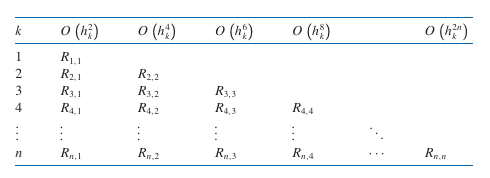

<center>

Este algoritmo permite añadir una nueva fila adicional de la regla compuesta trapezoidal con mucha facilidad.

In [83]:

import numpy as np

def romberg(f, a, b, n):
    
    h = (b-a)
    R = np.zeros((n,n))
    R[0,0] = (h/2)*(f(a) + f(b))

    for i in range(1,n):
        h = h/2
        suma = 0
        for k in range(1, 2**(i-1)+ 1):
            suma += f(a + (2*k - 1)*h)

        R[i,0] = 0.5*R[i-1,0]  + h*suma

        for j in range(1,i+1):

            R[i,j] = (4**(j)*R[i,j-1] - R[i-1,j-1])/(4**(j)-1)
        
    return R

def f(x):
    return np.sin(x)

R = romberg(f, 0, np.pi, 6)
print(R)
print(R[5,5])







[[1.92367069e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.57079633e+00 2.09439510e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.89611890e+00 2.00455975e+00 1.99857073e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.97423160e+00 2.00026917e+00 1.99998313e+00 2.00000555e+00
  0.00000000e+00 0.00000000e+00]
 [1.99357034e+00 2.00001659e+00 1.99999975e+00 2.00000002e+00
  1.99999999e+00 0.00000000e+00]
 [1.99839336e+00 2.00000103e+00 2.00000000e+00 2.00000000e+00
  2.00000000e+00 2.00000000e+00]]
2.0000000000013207


# Métodos de cuadratura adaptable

La cuadratura adaptativa es utilizada para funciones que varien mucho en partes de su dominio y con mayor lentitud en otras secciones. Permitiendo adaptar el tamaño del paso a diferencia de los pasos iguales de lo métodos anteriores. También permite estimar el error más facilmente teniendo en cuenta que para algunas funciones puede ser que calcular el error a través de las fórmulas compuestas puede ser complicado.

Para la regla del trapecio , por ejemplo:

$$\int_{a}^{b}f(x) dx = S_{[a,b]} - h^3\frac{f''(c_0)}{12}$$

para alguna $c_0$ entre a y b, donde h  = b - a. Estableciendo c como el punto medio de $[a,b]$ puede aplicarse la regla del trapecio a las dos mitades y obtener:

$$\int_{a}^{b}f(x) dx = S_{[a,c]} + S_{[c,b]} - (\frac{h}{2})^3\frac{f''(c_1)}{12} - (\frac{h}{2})^3\frac{f''(c_2)}{12}$$

$$\int_{a}^{b}f(x) dx = S_{[a,c]} + S_{[c,b]} - \frac{h^3}{4}\frac{f''(c_3)}{12}$$

Al restar la primera expresión con la expresión dividida en dos intervalos se obtiene:

$$s_{[a,b]} - (s_{[a,c]} + s_{[c,b]}) = - \frac{h^3}{4}\frac{f''(c_3)}{12} + h^3\frac{f''(c_0)}{12}$$

$$s_{[a,b]} - (s_{[a,c]} + s_{[c,b]}) \approx \frac{3h^3}{4}\frac{f''(c_3)}{12}$$

Aproximando $f''(c_3) \approx f''(c_0)$

Hay que notar que $s_{[a,b]} - (s_{[a,c]} + s_{[c,b]})$ es aproximadamente 3 veces el tamaño del error de la fórmula $s_{[a,c]} + s_{[c,b]}$ en $[a,b]$. Por lo tanto es posible comprobar si la expresión anterior es inferior a 3 veces la tolerancia, para alguna tolerancia arbitraria. Si el criterio no se cumple se puede subdividir nuevamente.




In [125]:
import numpy as np

def trapecio(a, b, f):
    h = (b-a)
    return (h/2)*(f(a) + f(b))

def simpson(a, b, f):
    x2 = (b + a)/2
    h = b - x2
    return (h/3)*(f(a) + 4*f(x2) + f(b))

def cuadratura_adaptativa(f, a, b, metodo, tol, factor):

    pila = []
    suma = 0
    s = metodo(a,b,f)

    while True:
    
        c = (a+b)/2
        s1 = metodo(a,c,f) 
        s2 = metodo(c,b,f)

        if np.abs((s - s1 - s2)/factor) < tol:
            suma += s1 + s2

            if not pila:
                return suma
            
            b, a, tol, s = pila.pop()


        else:
            tol = tol/2
            pila.append([b, c, tol, s2])
            b = c
            s = s1
            
            

def f(x):
    return (100/x**2)*np.sin(10/x)

print(f"Aproximación con cuadratura adaptativa: {cuadratura_adaptativa(f, 1, 3, simpson, 1e-4, 15)}")

print(f"Aproximación con trapecio: {trapecio(1, 3, f)}")

print(f"Aproximación con simpson: {simpson(1, 3, f)}")
            



            


    

Aproximación con cuadratura adaptativa: -1.4260192969841918
Aproximación con trapecio: -56.51953289866459
Aproximación con simpson: -50.80398678832614
